TimesNewRoman.ttf not found. Using DejaVu Serif.


,Sample ID,Briquette Type,Additive Type,Filter Pressing Type,Compression Strength (MPa),Durability (%)
0,Sample 1,TEP,Reference,Reference,0.532,46.96
1,Sample 2,TEI,PS+C,BF,0.654,53.28
2,Sample 3,TEI,PS+C,MIX,0.846,35.44
3,Sample 4,TEI,PS,AF,0.551,32.09
4,Sample 5,TEI,PS+C,AF,0.464,53.28
5,Sample 6,TEI,PS,BF,1.674,34.29


,Compression Strength (MPa),Durability (%)
Sample 1 | TEP | Industrial reference,0.532,46.96
Sample 2 | TEI | PS+C | BF,0.654,53.28
Sample 3 | TEI | PS+C | MIX,0.846,35.44
Sample 4 | TEI | PS | AF,0.551,32.09
Sample 5 | TEI | PS+C | AF,0.464,53.28
Sample 6 | TEI | PS | BF,1.674,34.29


,Compression strength,Durability
Sample 1 | TEP | Industrial reference,-0.614,0.493
Sample 2 | TEI | PS+C | BF,-0.320,1.202
Sample 3 | TEI | PS+C | MIX,0.143,-0.797
Sample 4 | TEI | PS | AF,-0.568,-1.173
Sample 5 | TEI | PS+C | AF,-0.778,1.202
Sample 6 | TEI | PS | BF,2.138,-0.926


Maximum Ward linkage distance: 3.885


,Cluster 1,Cluster 2,Ward linkage distance,Number of samples
0,1.0,4.0,0.458,2.0
1,2.0,3.0,0.804,2.0
2,0.0,6.0,0.821,3.0
3,5.0,7.0,2.716,3.0
4,8.0,9.0,3.885,6.0


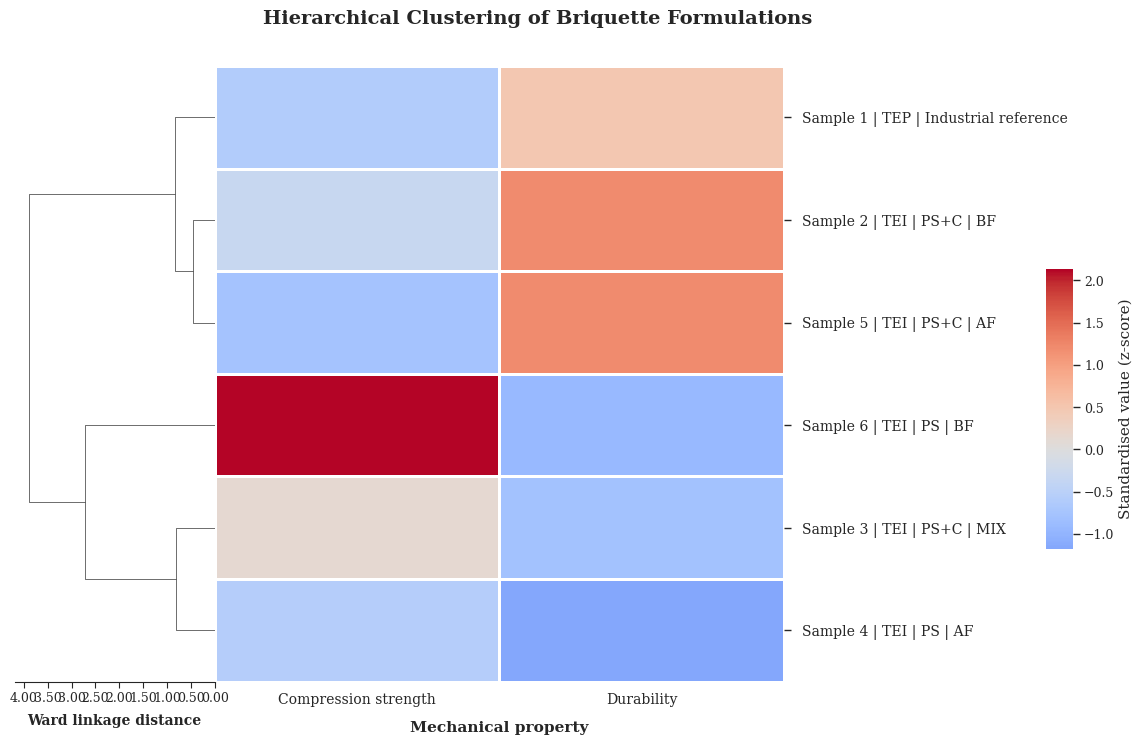

In [1]:
# ============================================================
# AI-Assisted Briquette Analysis
# Hierarchical Clustering of Briquette Formulations
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage


# ============================================================
# 1. Figure font configuration
# ============================================================
# To reproduce figures using Times New Roman in Google Colab,
# upload a legally obtained TimesNewRoman.ttf file to:
# /content/TimesNewRoman.ttf
#
# If unavailable, the notebook falls back to DejaVu Serif.

font_path = "/content/TimesNewRoman.ttf"

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    print(f"Font loaded: {font_name}")
else:
    font_name = "DejaVu Serif"
    print("TimesNewRoman.ttf not found. Using DejaVu Serif.")

mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["savefig.dpi"] = 600


# ============================================================
# 2. Experimental dataset
# ============================================================

briquette_data = {
    "Sample ID": [
        "Sample 1",
        "Sample 2",
        "Sample 3",
        "Sample 4",
        "Sample 5",
        "Sample 6"
    ],

    "Briquette Type": [
        "TEP",
        "TEI",
        "TEI",
        "TEI",
        "TEI",
        "TEI"
    ],

    "Additive Type": [
        "Reference",
        "PS+C",
        "PS+C",
        "PS",
        "PS+C",
        "PS"
    ],

    "Filter Pressing Type": [
        "Reference",
        "BF",
        "MIX",
        "AF",
        "AF",
        "BF"
    ],

    "Compression Strength (MPa)": [
        0.532,
        0.654,
        0.846,
        0.551,
        0.464,
        1.674
    ],

    "Durability (%)": [
        46.96,
        53.28,
        35.44,
        32.09,
        53.28,
        34.29
    ]
}

df = pd.DataFrame(briquette_data)

display(df)


# ============================================================
# 3. Prepare clustering dataset
# ============================================================
# Hierarchical clustering is based on:
#   - Compression strength (MPa)
#   - Durability (%)
# ============================================================

feature_columns = [
    "Compression Strength (MPa)",
    "Durability (%)"
]

cluster_data = df[
    ["Sample ID"] + feature_columns
].copy()


# ============================================================
# 4. Create descriptive sample labels
# ============================================================

sample_labels = []

for _, row in df.iterrows():

    sample_id = row["Sample ID"]
    briquette_type = row["Briquette Type"]
    additive_type = row["Additive Type"]
    pressing_type = row["Filter Pressing Type"]

    if sample_id == "Sample 1":
        label = (
            f"{sample_id} | "
            f"{briquette_type} | "
            "Industrial reference"
        )
    else:
        label = (
            f"{sample_id} | "
            f"{briquette_type} | "
            f"{additive_type} | "
            f"{pressing_type}"
        )

    sample_labels.append(label)


cluster_data = cluster_data.set_index("Sample ID")

cluster_data.index = sample_labels

cluster_data = cluster_data[feature_columns]

display(cluster_data)


# ============================================================
# 5. Standardisation using z-scores
# ============================================================
# Standardisation prevents differences in measurement scale
# from dominating the clustering analysis.
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_data
)

scaled_df = pd.DataFrame(
    X_scaled,
    index=cluster_data.index,
    columns=[
        "Compression strength",
        "Durability"
    ]
)

display(scaled_df.round(3))


# ============================================================
# 6. Ward hierarchical clustering
# ============================================================
# Ward linkage is applied to the standardized mechanical
# properties using Euclidean distance.
# ============================================================

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

max_distance = Z[:, 2].max()

print(
    "Maximum Ward linkage distance:",
    round(max_distance, 3)
)


# ============================================================
# 7. Numerical Ward linkage results
# ============================================================

linkage_df = pd.DataFrame(
    Z,
    columns=[
        "Cluster 1",
        "Cluster 2",
        "Ward linkage distance",
        "Number of samples"
    ]
)

display(linkage_df.round(3))


# ============================================================
# 8. Hierarchical clustermap
# ============================================================

sns.set_theme(
    context="paper",
    style="white",
    font=font_name,
    font_scale=1.15
)

g = sns.clustermap(
    scaled_df,

    row_linkage=Z,
    col_cluster=False,

    cmap="coolwarm",
    center=0,

    linewidths=0.8,
    linecolor="white",

    figsize=(10.8, 7.0),

    dendrogram_ratio=(0.26, 0.04),

    cbar_pos=(0.97, 0.25, 0.025, 0.40),

    cbar_kws={
        "label": "Standardised value (z-score)"
    }
)


# ============================================================
# 9. Heatmap formatting
# ============================================================

g.ax_heatmap.set_xlabel(
    "Mechanical property",
    fontname=font_name,
    fontweight="bold",
    labelpad=10
)

g.ax_heatmap.set_ylabel("")

g.ax_heatmap.yaxis.tick_right()

g.ax_heatmap.tick_params(
    axis="y",
    labelright=True,
    labelleft=False,
    pad=8
)

g.ax_heatmap.set_xticklabels(
    [
        "Compression strength",
        "Durability"
    ],
    rotation=0,
    fontname=font_name
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontname=font_name
)


# ============================================================
# 10. Ward linkage distance axis
# ============================================================

ax_den = g.ax_row_dendrogram

ax_den.set_axis_on()

# Maximum distance appears on the left.
# Zero is adjacent to the heatmap.
ax_den.set_xlim(
    max_distance * 1.08,
    0
)

# Select tick interval automatically.
if max_distance <= 2:
    tick_step = 0.25
elif max_distance <= 5:
    tick_step = 0.5
else:
    tick_step = 1.0

ward_ticks = np.arange(
    0,
    np.ceil(max_distance / tick_step)
    * tick_step + tick_step,
    tick_step
)

ax_den.set_xticks(ward_ticks)

ax_den.set_xticklabels(
    [f"{value:.2f}" for value in ward_ticks],
    fontsize=9,
    fontname=font_name
)

ax_den.tick_params(
    axis="x",
    which="both",
    bottom=True,
    labelbottom=True,
    top=False,
    labeltop=False,
    length=4,
    width=0.8,
    pad=3
)

ax_den.set_yticks([])

ax_den.tick_params(
    axis="y",
    left=False,
    right=False,
    labelleft=False,
    labelright=False
)

ax_den.set_xlabel(
    "Ward linkage distance",
    fontsize=10,
    fontname=font_name,
    fontweight="bold",
    labelpad=7
)

ax_den.spines["bottom"].set_visible(True)
ax_den.spines["bottom"].set_linewidth(0.8)

ax_den.spines["top"].set_visible(False)
ax_den.spines["left"].set_visible(False)
ax_den.spines["right"].set_visible(False)


# ============================================================
# 11. Colour-bar formatting
# ============================================================

g.cax.set_ylabel(
    "Standardised value (z-score)",
    fontname=font_name,
    fontsize=11,
    rotation=90,
    labelpad=3
)

for label in g.cax.get_yticklabels():
    label.set_fontname(font_name)
    label.set_fontsize(9)


# ============================================================
# 12. Figure title
# ============================================================

g.fig.suptitle(
    "Hierarchical Clustering of Briquette Formulations",
    fontname=font_name,
    fontsize=14,
    fontweight="bold",
    y=1.02
)


# Apply selected font explicitly
for ax in [
    g.ax_heatmap,
    g.ax_row_dendrogram,
    g.cax
]:
    for label in ax.get_xticklabels():
        label.set_fontname(font_name)

    for label in ax.get_yticklabels():
        label.set_fontname(font_name)


# ============================================================
# 13. Save clustering figure
# ============================================================

output_base = "Briquette_Hierarchical_Clustermap_Ward_Axis"

g.fig.savefig(
    output_base + ".png",
    dpi=600,
    bbox_inches="tight"
)

g.fig.savefig(
    output_base + ".jpg",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

g.fig.savefig(
    output_base + ".tiff",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()